In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("standard_scaled_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (14992, 8)


,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,-0.052560,-0.021265,-2.647285,-2.999948,0.201022,0.057978,0.032341,1112
1,0.098135,-0.019743,3.761850,-2.926318,0.206570,0.058263,0.021627,1111
2,0.097669,-0.024052,3.795231,-2.893594,0.206570,0.058263,0.018539,1110
3,0.097410,-0.026418,3.806358,-2.885413,0.205780,0.058263,0.014771,1109
4,1.901905,2.053925,4.251437,-1.470097,0.203399,1.948155,1.805569,1107


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14992 entries, 0 to 14991
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Discharge Time (s)         14992 non-null  float64
 1   Decrement 3.6-3.4V (s)     14992 non-null  float64
 2   Max. Voltage Dischar. (V)  14992 non-null  float64
 3   Min. Voltage Charg. (V)    14992 non-null  float64
 4   Time at 4.15V (s)          14992 non-null  float64
 5   Time constant current (s)  14992 non-null  float64
 6   Charging time (s)          14992 non-null  float64
 7   RUL                        14992 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 937.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Discharge Time (s),14992.0,4.905361e-17,1.000000,-0.133541,-0.097130,-0.085051,-0.074078,29.869077
Decrement 3.6-3.4V (s),14992.0,4.549900e-17,1.000000,-0.102379,-0.081418,-0.072779,-0.061078,29.341588
Max. Voltage Dischar. (V),14992.0,-6.331944e-16,1.000000,-9.623896,-0.688939,-0.021320,0.713060,5.063706
Min. Voltage Charg. (V),14992.0,-2.983976e-15,1.000000,-4.546160,-0.733806,-0.038419,0.697872,5.909180
Time at 4.15V (s),14992.0,4.265531e-18,1.000000,-0.415757,-0.209263,-0.085472,0.045136,27.341484
Time constant current (s),14992.0,1.753607e-17,1.000000,-0.216608,-0.112520,-0.061258,-0.012923,35.615801
Charging time (s),14992.0,7.109219e-17,1.000000,-0.383604,-0.080860,-0.062503,-0.045488,33.624655
RUL,14992.0,5.549416e+02,322.175186,0.000000,279.000000,551.000000,840.000000,1133.000000


In [8]:
df.isnull().sum()

Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
np.isinf(df.select_dtypes(include=np.number)).sum()

Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

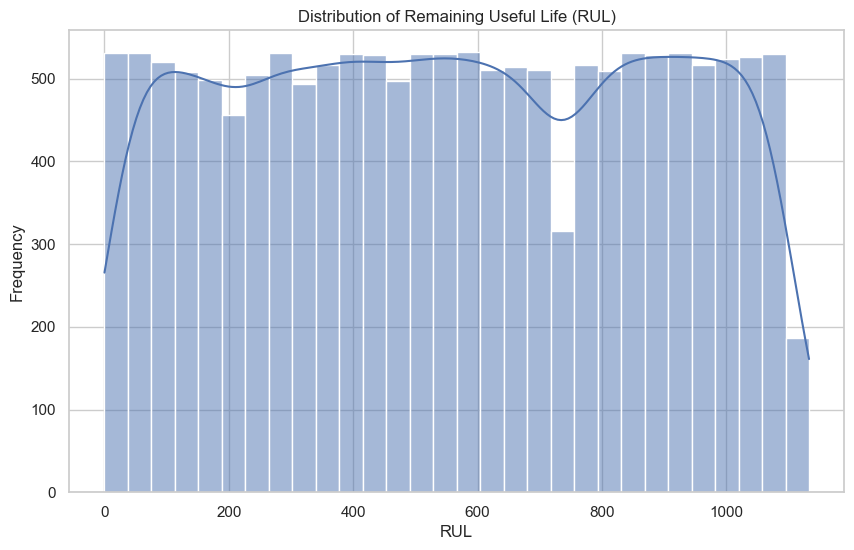

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["RUL"],
    bins=30,
    kde=True
)

plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL")
plt.ylabel("Frequency")

plt.show()

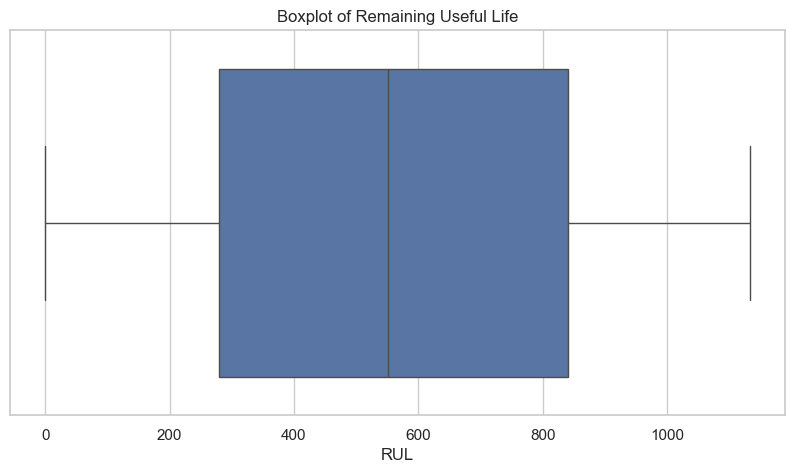

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["RUL"])

plt.title("Boxplot of Remaining Useful Life")
plt.xlabel("RUL")

plt.show()

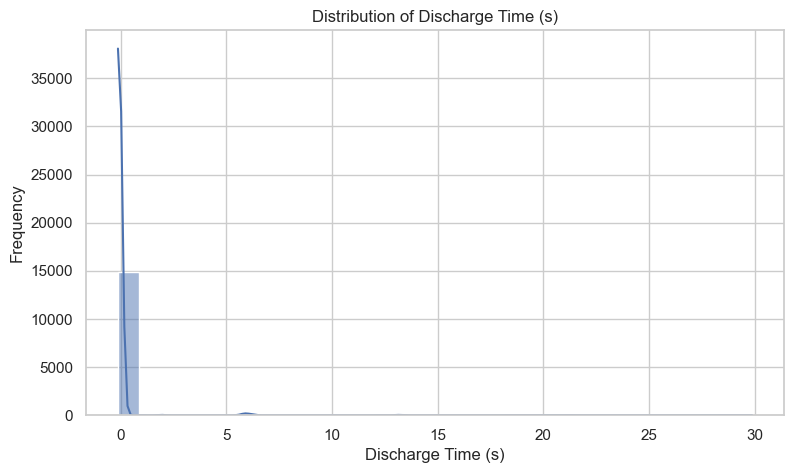

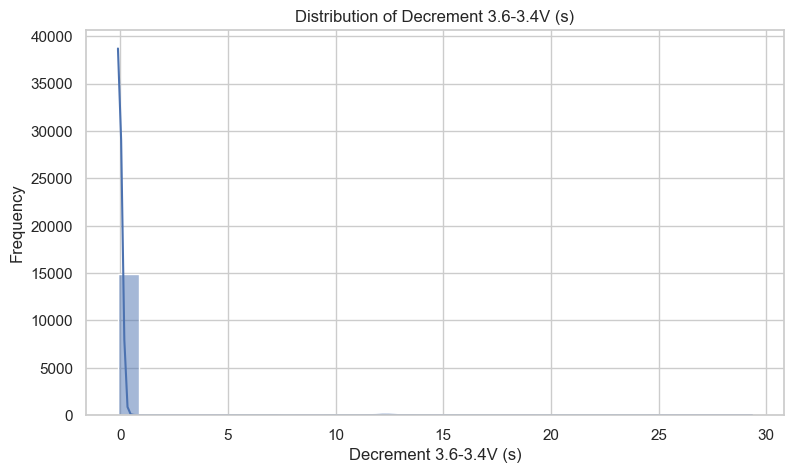

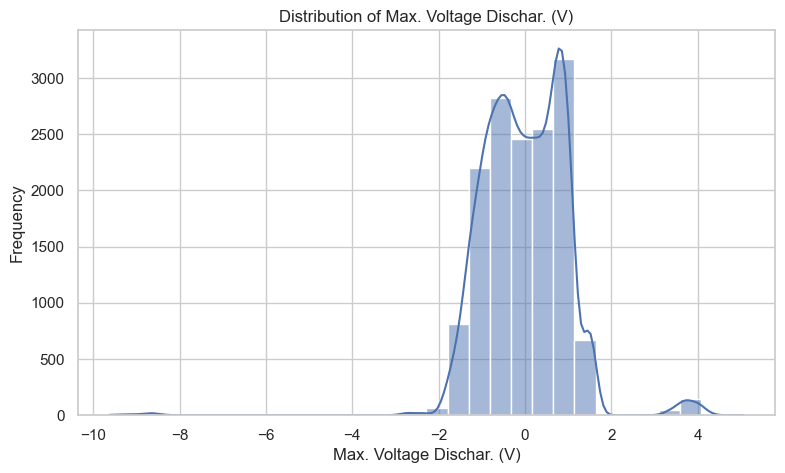

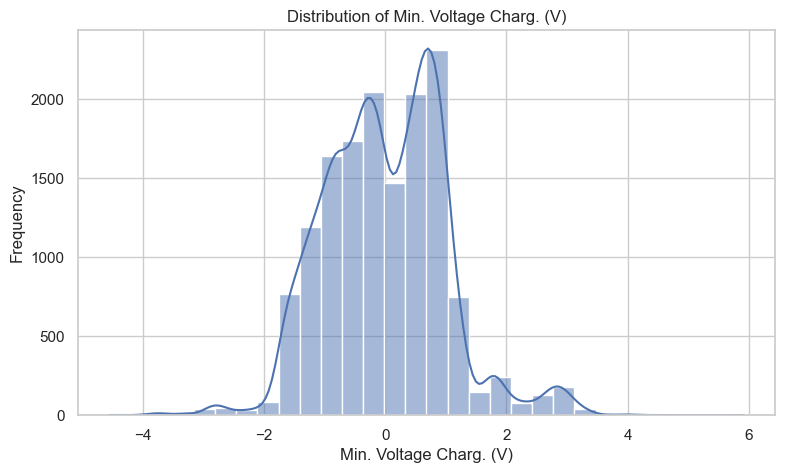

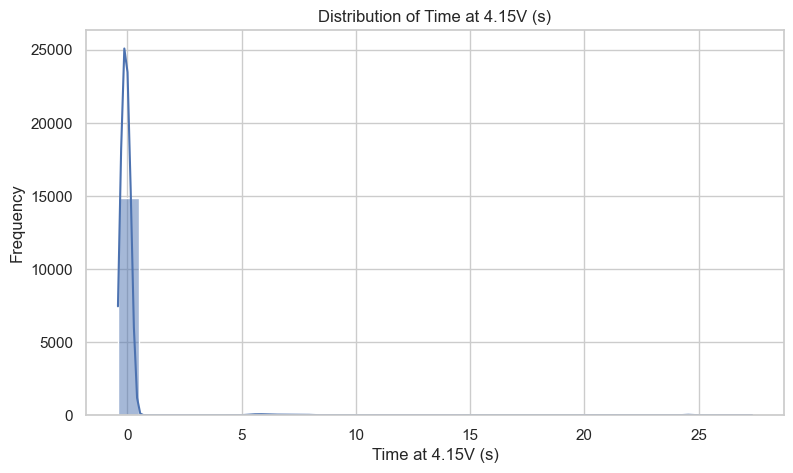

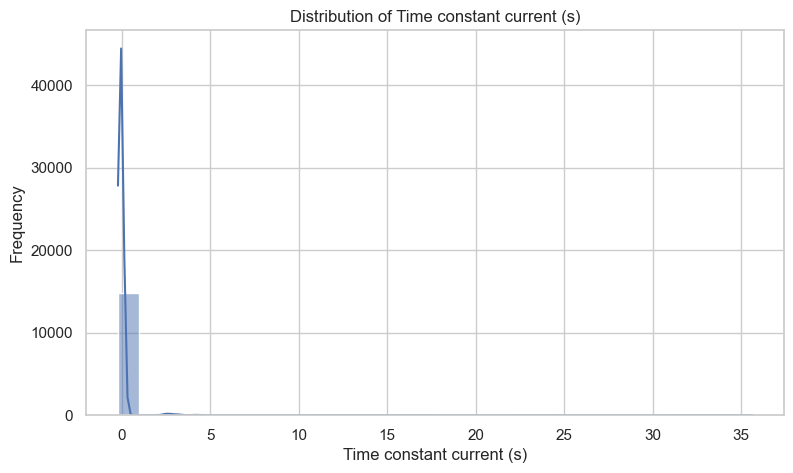

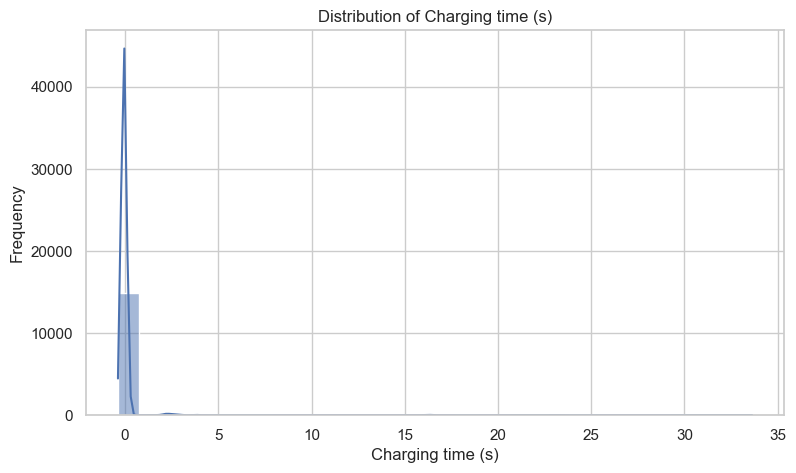

In [13]:
features = df.drop(columns=["RUL"]).columns

for feature in features:
    plt.figure(figsize=(9, 5))
    
    sns.histplot(
        df[feature],
        kde=True,
        bins=30
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.show()

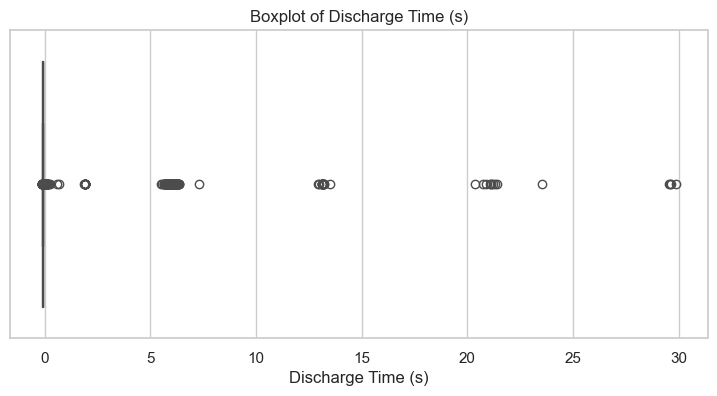

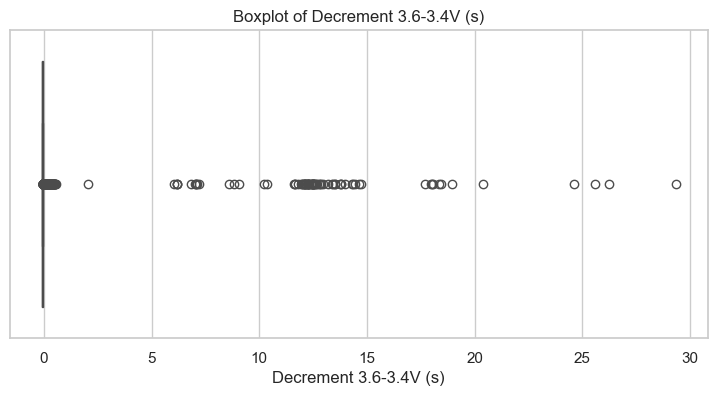

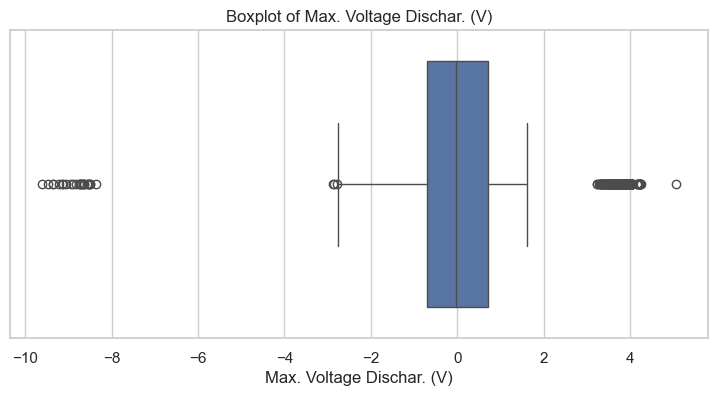

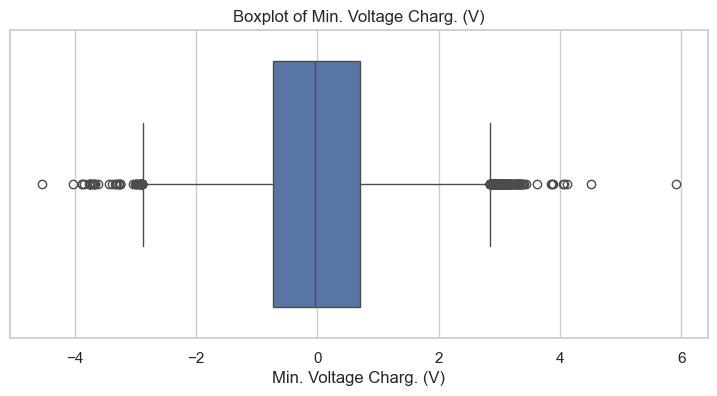

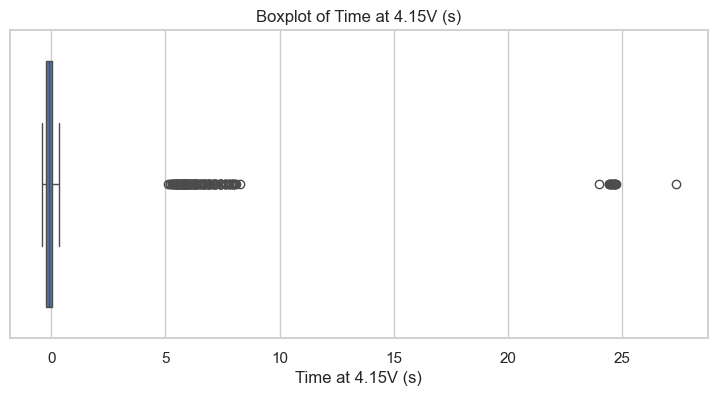

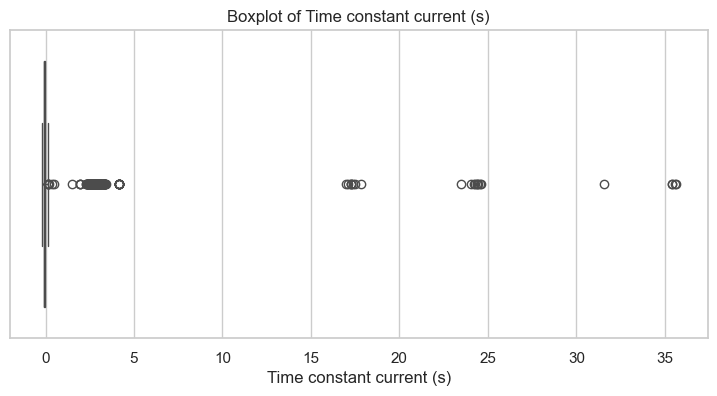

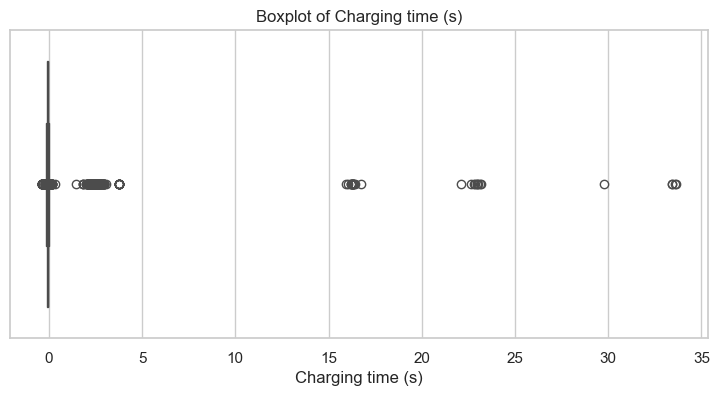

In [14]:
for feature in features:
    plt.figure(figsize=(9, 4))
    
    sns.boxplot(x=df[feature])
    
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    
    plt.show()

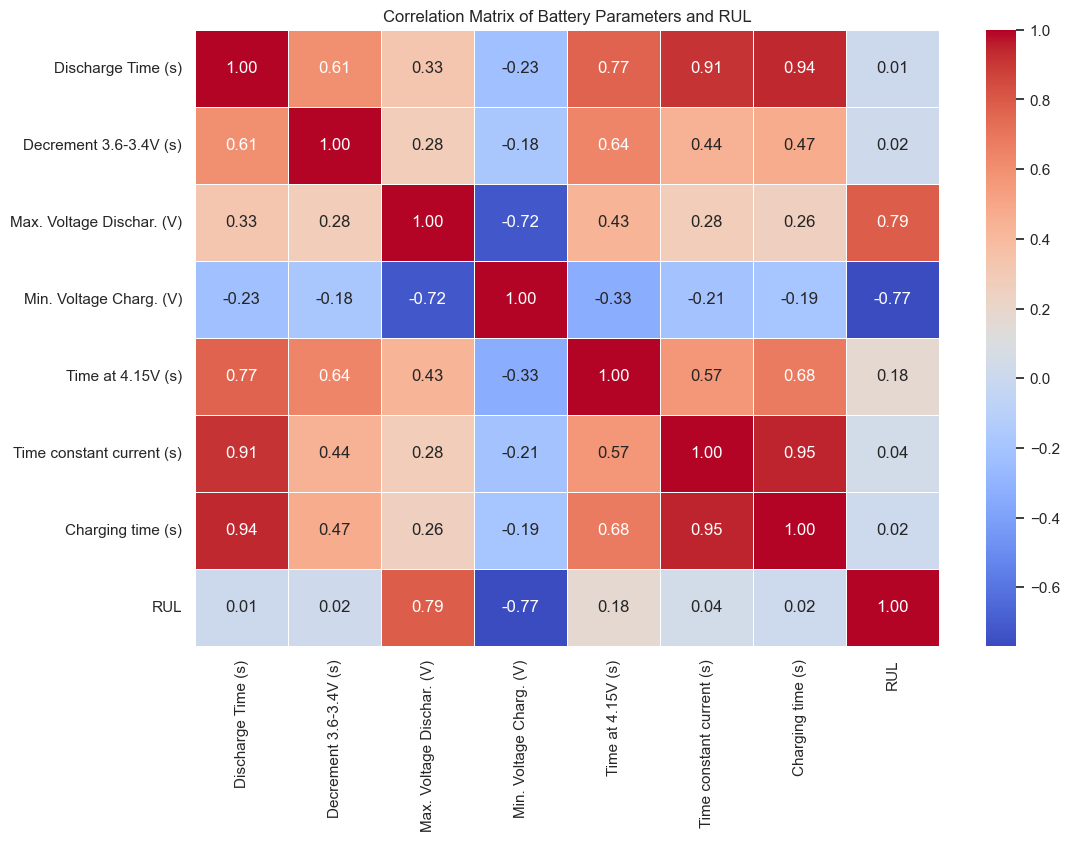

In [15]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Battery Parameters and RUL")

plt.show()

In [20]:
X = df.drop(columns=["RUL"])
y = df["RUL"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [31]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])


rf_pipeline.fit(X_train, y_train)

rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

In [30]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_train_pred = gb_pipeline.predict(X_train)
gb_test_pred = gb_pipeline.predict(X_test)

In [29]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_train_pred = xgb_pipeline.predict(X_train)
xgb_test_pred = xgb_pipeline.predict(X_test)

In [32]:
lgbm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LGBMRegressor(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)

lgbm_train_pred = lgbm_pipeline.predict(X_train)
lgbm_test_pred = lgbm_pipeline.predict(X_test)

In [33]:
models = {
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

print("Models available:")

for name in models:
    print("-", name)

Models available:
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


In [35]:
train_predictions = {
    "Random Forest": rf_train_pred,
    "Gradient Boosting": gb_train_pred,
    "XGBoost": xgb_train_pred,
    "LightGBM": lgbm_train_pred
}

test_predictions = {
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_test_pred,
    "XGBoost": xgb_test_pred,
    "LightGBM": lgbm_test_pred
}

In [36]:
baseline_results = []

for name in models:

    train_pred = train_predictions[name]
    test_pred = test_predictions[name]

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    baseline_results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,3.633786,9.564478,7.847546,21.240654,0.999409,0.995568
1,Gradient Boosting,29.640929,30.433715,40.037801,41.618656,0.984629,0.982985
2,XGBoost,8.701430,13.559671,12.932684,22.353508,0.998396,0.995092
3,LightGBM,17.077699,19.513659,24.719169,31.341030,0.994141,0.990351


In [37]:
baseline_results_df.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,3.633786,9.564478,7.847546,21.240654,0.999409,0.995568
1,XGBoost,8.701430,13.559671,12.932684,22.353508,0.998396,0.995092
2,LightGBM,17.077699,19.513659,24.719169,31.341030,0.994141,0.990351
3,Gradient Boosting,29.640929,30.433715,40.037801,41.618656,0.984629,0.982985


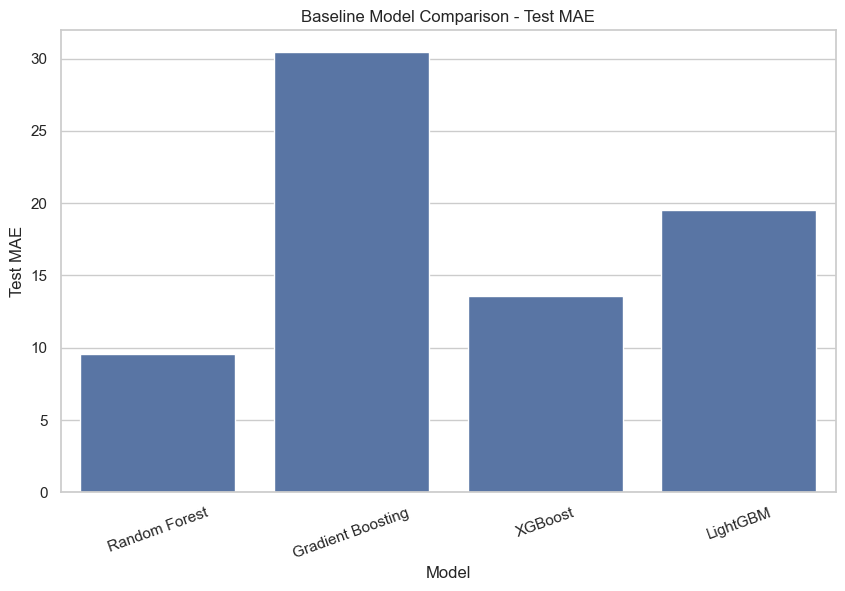

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="Test MAE"
)

plt.title("Baseline Model Comparison - Test MAE")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=20)

plt.show()

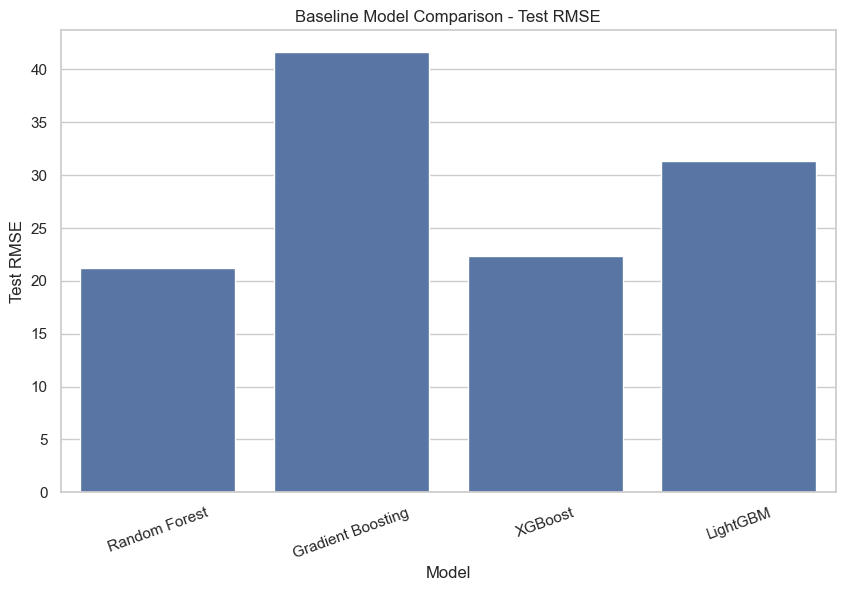

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="Test RMSE"
)

plt.title("Baseline Model Comparison - Test RMSE")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20)

plt.show()

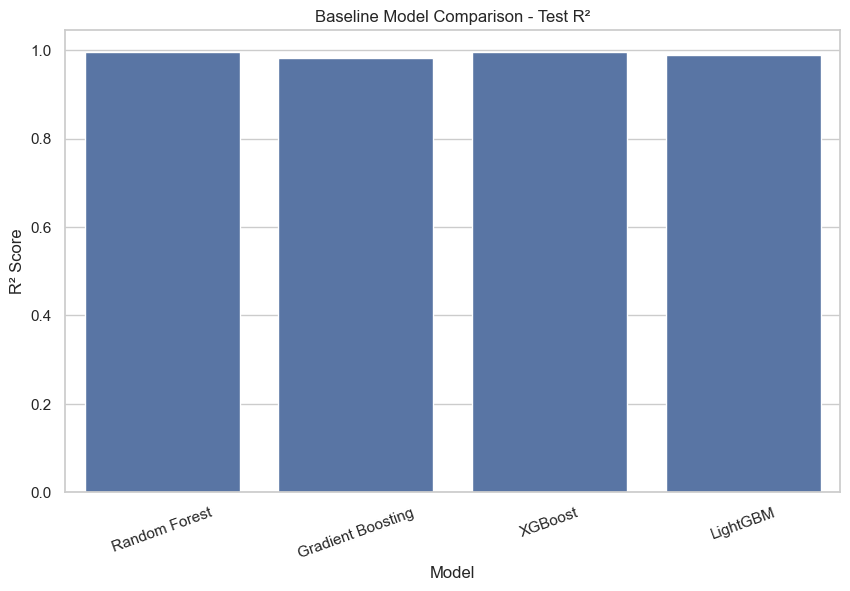

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_df,
    x="Model",
    y="Test R²"
)

plt.title("Baseline Model Comparison - Test R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()

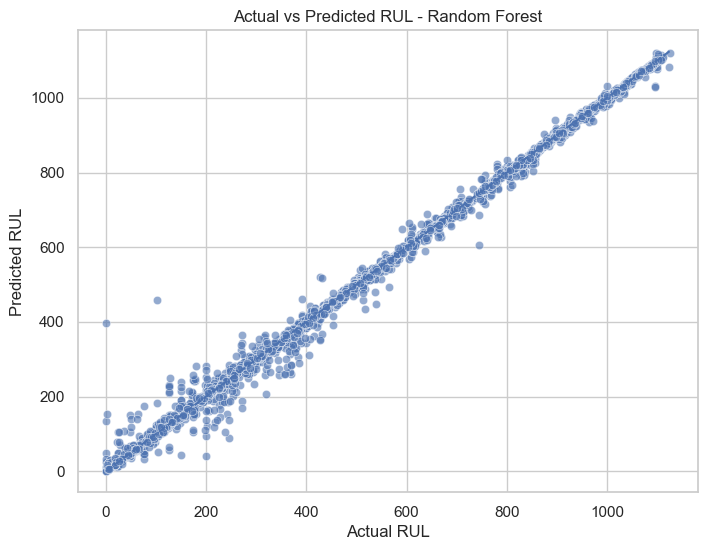

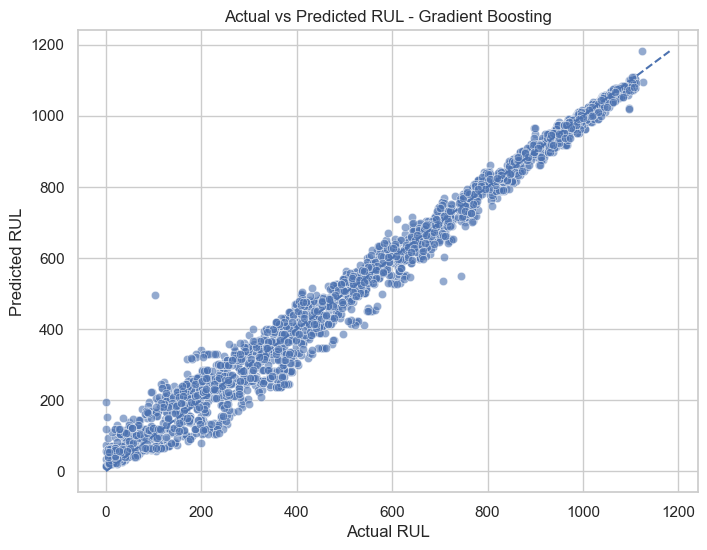

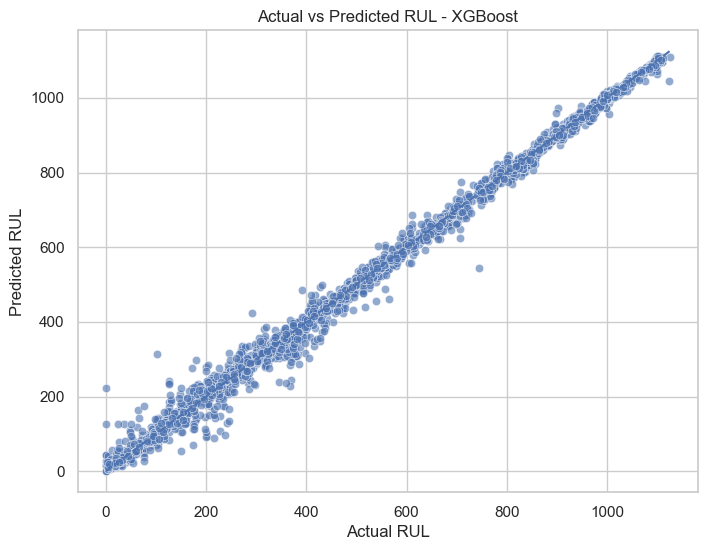

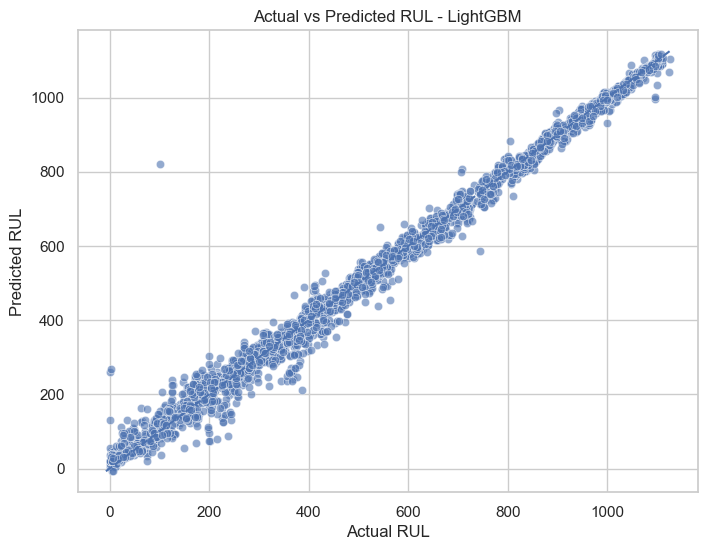

In [ ]:
for name in models:
    predictions = test_predictions[name]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=y_test,
        y=predictions,
        alpha=0.6
    )
    min_value = min(
        y_test.min(),
        predictions.min()
    )
    max_value = max(
        y_test.max(),
        predictions.max()
    )
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )
    plt.title(f"Actual vs Predicted RUL - {name}")
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.show()

In [43]:
cv = 5

In [44]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error', verbose=1)

In [45]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation MAE:")
print(-rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Best Cross-Validation MAE:
10.86293719676564


In [46]:
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=None,
                                                     early_stopping_rounds=None,
                                                     enable_categorical=False,
                                                     eval_metric=None,
                                                     feature_types=None,
                                                     feature_weights=None,
                                                     gamma=None,
                                                     grow_policy=N...
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error', verbose=1)

In [47]:
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest Cross-Validation MAE:")
print(-xgb_grid.best_score_)

Best XGBoost Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}

Best Cross-Validation MAE:
18.5405517578125


In [48]:
lgbm_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [15, 31],
    "model__max_depth": [-1, 5],
    "model__min_child_samples": [10, 20]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=lgbm_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LGBMRegressor(n_jobs=-1,
                                                      random_state=42,
                                                      verbosity=-1))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [-1, 5],
                         'model__min_child_samples': [10, 20],
                         'model__n_estimators': [100, 200],
                         'model__num_leaves': [15, 31]},
             scoring='neg_mean_absolute_error', verbose=1)

In [49]:
print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)

print("\nBest Cross-Validation MAE:")
print(-lgbm_grid.best_score_)

Best LightGBM Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': -1, 'model__min_child_samples': 10, 'model__n_estimators': 200, 'model__num_leaves': 31}

Best Cross-Validation MAE:
16.328101078269615


In [50]:
gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error', verbose=1)

In [51]:
print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation MAE:")
print(-gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best Cross-Validation MAE:
20.529602054795074


In [52]:
optimized_models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "LightGBM": lgbm_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

print("Optimized models created successfully.")

for name in optimized_models:
    print("-", name)

Optimized models created successfully.
- Random Forest
- XGBoost
- LightGBM
- Gradient Boosting


In [53]:
optimized_predictions = {}

for name, model in optimized_models.items():
    optimized_predictions[name] = model.predict(X_test)

In [54]:
optimized_results = []

for name, model in optimized_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    optimized_results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

optimized_results_df = pd.DataFrame(
    optimized_results
)

optimized_results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,3.595086,9.479165,7.755954,21.113064,0.999423,0.995621
1,XGBoost,15.016249,18.005213,21.341744,26.978874,0.995633,0.992850
2,LightGBM,12.536272,15.953192,18.077276,26.860124,0.996866,0.992913
3,Gradient Boosting,16.979811,20.452871,23.463768,30.991630,0.994721,0.990565


In [55]:
baseline_comparison = baseline_results_df[
    [
        "Model",
        "Test MAE",
        "Test RMSE",
        "Test R²"
    ]
].copy()

baseline_comparison["Type"] = "Baseline"


optimized_comparison = optimized_results_df[
    [
        "Model",
        "Test MAE",
        "Test RMSE",
        "Test R²"
    ]
].copy()

optimized_comparison["Type"] = "Optimized"


final_comparison = pd.concat(
    [
        baseline_comparison,
        optimized_comparison
    ],
    ignore_index=True
)

final_comparison

,Model,Test MAE,Test RMSE,Test R²,Type
0,Random Forest,9.564478,21.240654,0.995568,Baseline
1,Gradient Boosting,30.433715,41.618656,0.982985,Baseline
2,XGBoost,13.559671,22.353508,0.995092,Baseline
3,LightGBM,19.513659,31.341030,0.990351,Baseline
4,Random Forest,9.479165,21.113064,0.995621,Optimized
5,XGBoost,18.005213,26.978874,0.992850,Optimized
6,LightGBM,15.953192,26.860124,0.992913,Optimized
7,Gradient Boosting,20.452871,30.991630,0.990565,Optimized


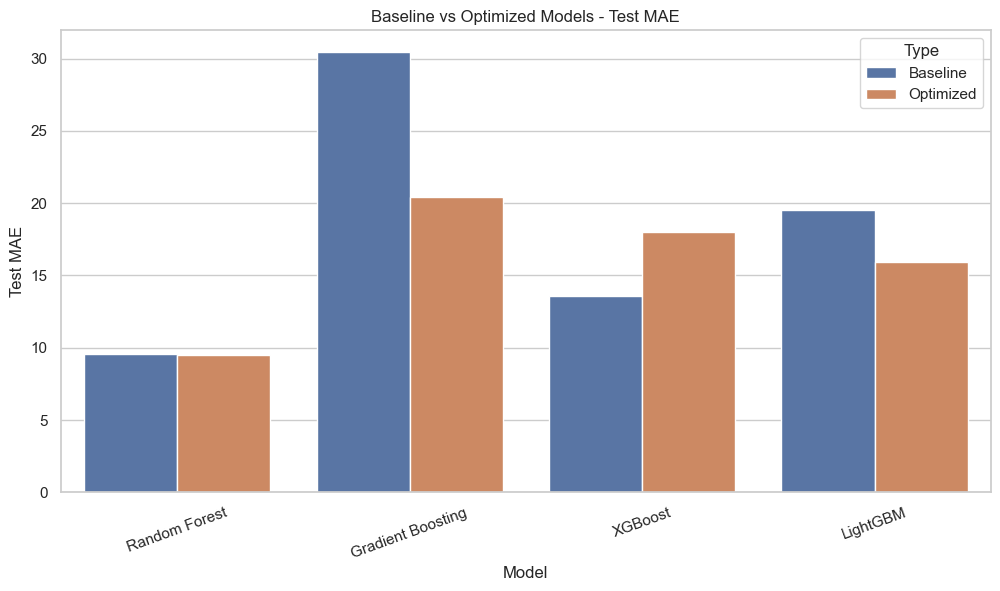

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Test MAE",
    hue="Type"
)

plt.title("Baseline vs Optimized Models - Test MAE")
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.xticks(rotation=20)

plt.show()

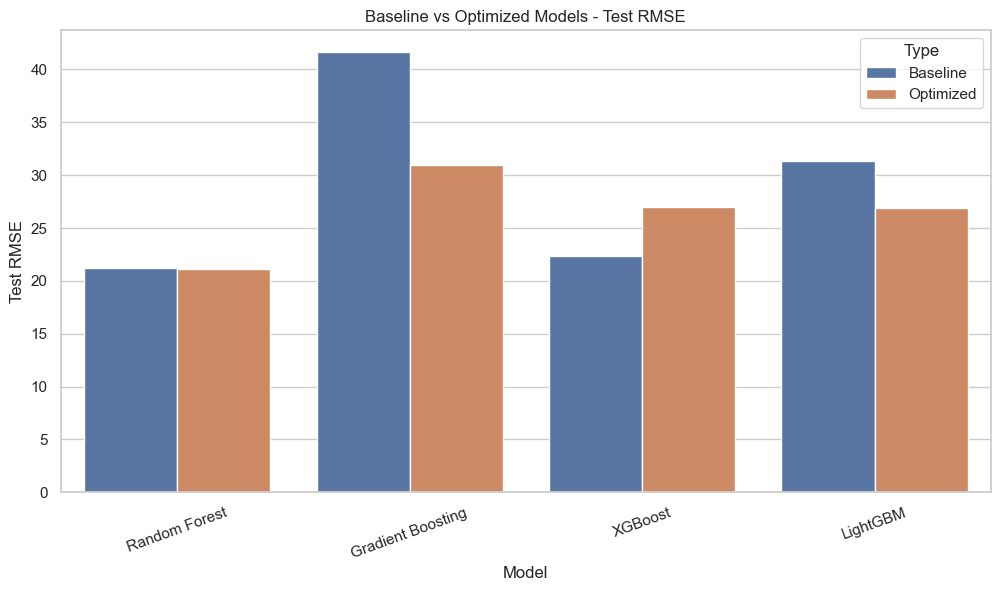

In [57]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Test RMSE",
    hue="Type"
)

plt.title("Baseline vs Optimized Models - Test RMSE")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20)

plt.show()

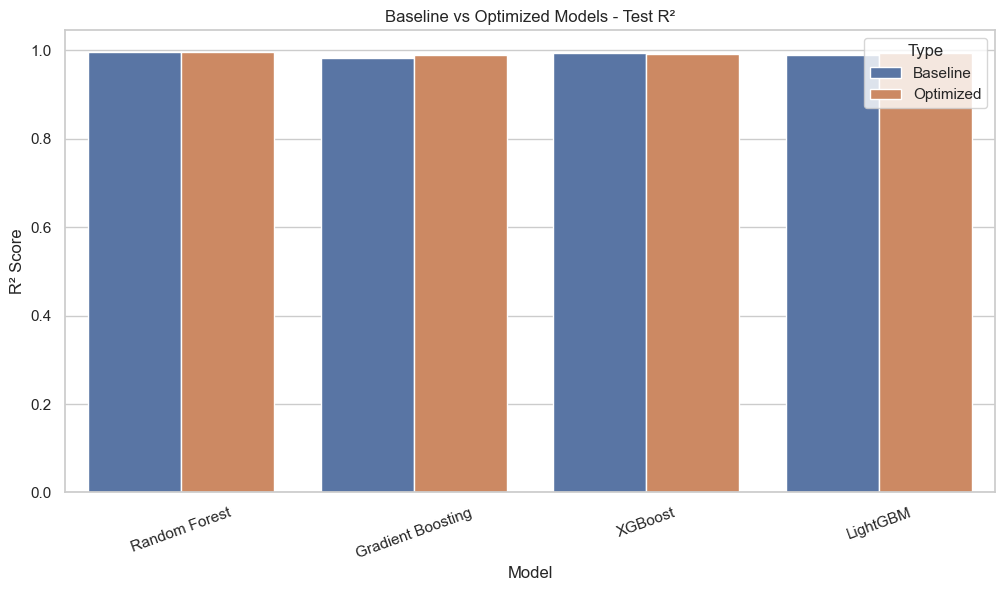

In [58]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Test R²",
    hue="Type"
)

plt.title("Baseline vs Optimized Models - Test R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()

In [59]:
optimized_results_df.sort_values(
    by=["Test R²", "Test MAE", "Test RMSE"],
    ascending=[False, True, True]
).reset_index(drop=True)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,3.595086,9.479165,7.755954,21.113064,0.999423,0.995621
1,LightGBM,12.536272,15.953192,18.077276,26.860124,0.996866,0.992913
2,XGBoost,15.016249,18.005213,21.341744,26.978874,0.995633,0.992850
3,Gradient Boosting,16.979811,20.452871,23.463768,30.991630,0.994721,0.990565


In [60]:
best_model_name = optimized_results_df.sort_values(
    by="Test R²",
    ascending=False
).iloc[0]["Model"]

print("Best Optimized Model:", best_model_name)

Best Optimized Model: Random Forest
